In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report,accuracy_score
from joblib import dump, load

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from scipy.stats import mode
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.preprocessing import Binarizer
from sklearn.neural_network import MLPClassifier

from xai_aux import CFCalculations, simulate_noise_effect

In [2]:
warnings.filterwarnings("ignore", message="X has feature names, but RandomForestClassifier was fitted without feature names")
warnings.filterwarnings("ignore", message="X has feature names, but LogisticRegression was fitted without feature names")
warnings.filterwarnings("ignore", message="X does not have valid feature names, but OneHotEncoder was fitted with feature names")
warnings.filterwarnings("ignore", message="X does not have valid feature names, but StandardScaler was fitted with feature names")
warnings.simplefilter(action="ignore", category=pd.errors.PerformanceWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings("ignore", message=".*At this time, the v2.11\\+ optimizer.*")

In [3]:
# inputs
mock_data = 3
cat_mock_data = True
non_iid = False

In [4]:
def plot_decision_boundary(clf, X, y, title, ax):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.01),
        np.arange(y_min, y_max, 0.01)
    )
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Paired)
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k", cmap=plt.cm.Paired)
    ax.set_title(title)

# Function to add feature noise
def add_feature_noise(X, noise_level):
    noise = np.random.normal(0, noise_level, X.shape)
    return X + noise

# Function to flip labels
def flip_labels(y, flip_fraction):
    n_flips = int(len(y) * flip_fraction)
    flip_indices = np.random.choice(len(y), n_flips, replace=False)
    y_noisy = y.copy()
    y_noisy[flip_indices] = 1 - y_noisy[flip_indices]  # Flip binary labels
    return y_noisy

In [5]:
# Function to add noise
def add_noise(df, num_feat, cat_feat, noise_level):
    noisy_df = df.copy()
    
    # Add noise to numerical features
    for col in num_feat:
        std_dev = np.std(df[col].astype(float))
        noise = np.random.normal(0, noise_level * std_dev, size=len(df))
        noisy_df[col] = df[col].astype(float) + noise
    
    # Add noise to categorical features
    for col in cat_feat:
        mask = np.random.rand(len(df)) < noise_level
        shuffled = np.random.permutation(df[col])
        noisy_df.loc[mask, col] = shuffled[mask]
    
    return noisy_df

def simulate_noise_effect(df, num_feat, cat_feat, y, max_noise=1.5, step=0.05):
    results = []
    noise_levels = np.arange(0, max_noise + step, step)
    label_flip_fractions = np.linspace(0, 0.2, 11) 
    
    datasets = []
    for ii, noise_level in enumerate(noise_levels):
        df_noisy = add_noise(df, num_feat, cat_feat, noise_level)
        y_noisy = flip_labels(y, label_flip_fractions[ii])
        
        pp = Pipeline([
                ('PP', ColumnTransformer([
                    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_feat), 
                    ('num', StandardScaler(), num_feat)],
                    #('num', 'passthrough', num_feat)], 
                    remainder='passthrough'
                    )),
                ])

        X_train, X_test, y_train, y_test = train_test_split(df_noisy, y_noisy, test_size=0.3, random_state=42)
        clf = Pipeline([('PP', pp), ('NN', MLPClassifier(max_iter=1000))])
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        results.append((noise_level, accuracy))
        datasets.append([df_noisy,y_noisy])
    return results, datasets

In [6]:
if not cat_mock_data:
    if mock_data==1:
        n_samples = 3000
        n_features = 2
        n_informative = 2
        n_redundant = 0
        class_sep = 1
        flip_y=0.01
        cat_feat = []
        num_feat = [i for i in range(n_features)]
        polytopes = []
    elif mock_data==2:
        n_samples = 3000
        n_features = 12
        n_informative = 10
        n_redundant = 2
        class_sep = 3 # 1
        flip_y=0.01
        cat_feat = []
        num_feat = [i for i in range(n_features)]
        polytopes = []
    else:
        pass

    X, y = make_classification(
        n_samples=n_samples, n_features=n_features, n_informative=n_informative,
        weights = [0.6], n_redundant=n_redundant, class_sep=class_sep, flip_y=0.005, random_state=42
    )

    # Store results
    results = []
    datasets = [[X,y]]
    decision_boundary_models = []
    decision_boundary_datasets = []

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    steps = 11 # first step is the default
    feature_noise_levels = np.linspace(0, 1., steps)  # Adjust range to control feature noise impact
    label_flip_fractions = np.linspace(0, 0.2, steps)  # Adjust range to control label noise impact

    # Loop through combinations of feature noise and label noise
    for feature_noise_level, label_flip_fraction in zip(feature_noise_levels, label_flip_fractions):

        # Add feature noise
        X_noisy = add_feature_noise(X, feature_noise_level)
        # Add label noise
        y_noisy = flip_labels(y, label_flip_fraction)

        X_train_noisy, X_test_noisy, y_train_noisy, y_test_noisy = train_test_split(
            X_noisy, y_noisy, test_size=0.3, random_state=42
        )

        datasets.append([X_noisy,y_noisy])
        decision_boundary_datasets.append([X_test_noisy,y_test_noisy])

        # Train classifier
        #clf = DecisionTreeClassifier(random_state=42)
        #clf = LogisticRegression(random_state=42)
        clf = MLPClassifier()
        clf.fit(X_train_noisy, y_train_noisy)
        
        decision_boundary_models.append(clf)

        # Predict and calculate accuracy
        y_pred = clf.predict(X_test_noisy)
        accuracy = accuracy_score(y_test_noisy, y_pred)

        # Store results
        results.append({
            'feature_noise_level': feature_noise_level,
            'label_flip_fraction': label_flip_fraction,
            'accuracy': accuracy
        })

    # Convert results to DataFrame for further analysis
    results_df = pd.DataFrame(results)

    # Display results
    print(results_df)

    # Optional: Visualize accuracies
    plt.figure(figsize=(8, 6))
    plt.plot(np.arange(0, steps), results_df['accuracy'], marker='o', label='Accuracy')
    plt.xlabel('Noise')
    plt.ylabel('Accuracy')
    plt.title('Accuracy vs. Noise Levels')
    plt.grid()
    plt.xticks(ticks=np.arange(0, steps), labels=[f"Level {i}" for i in range(0, steps)])
    plt.show()

    # Plot feature noise vs. label noise impact
    plt.figure(figsize=(8, 6))
    plt.scatter(results_df['feature_noise_level'], results_df['accuracy'], c='blue', label='Feature Noise')
    plt.scatter(results_df['label_flip_fraction'], results_df['accuracy'], c='orange', label='Label Noise')
    plt.xlabel('Noise Level')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Impact of Noise Levels on Accuracy')
    plt.grid()
    plt.show()

    if n_features==2:
        # Visualization
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        plot_decision_boundary(decision_boundary_models[0], decision_boundary_datasets[0][0], decision_boundary_datasets[0][1], f"Original (Accuracy: {results_df['accuracy'][0]:.2f})", axes[0])
        plot_decision_boundary(decision_boundary_models[4], decision_boundary_datasets[4][0], decision_boundary_datasets[4][1], f"Halfway Noise (Accuracy: {results_df['accuracy'][4]:.2f})", axes[1])
        plot_decision_boundary(decision_boundary_models[-1], decision_boundary_datasets[-1][0], decision_boundary_datasets[-1][1], f"Full Noise (Accuracy: {results_df['accuracy'].values[-1]:.2f})", axes[2])
        plt.tight_layout()
        plt.show()

/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warning

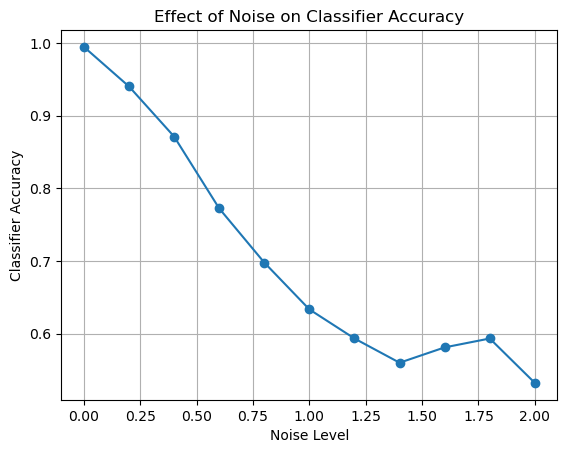

In [7]:
if mock_data==3 and cat_mock_data:
    n_samples = 3000
    n_features = 10
    n_informative = 10
    n_redundant = 0
    class_sep = 3 # 1
    flip_y=0.01
    cat_feat = [0, 1, 2, 3, 4]
    num_feat = [5, 6, 7, 8, 9]
    polytopes = [[1,2,3],[4,5,6]]
    X, y = make_classification(
        n_samples=n_samples, n_features=n_features, n_informative=10,
        weights = [0.6], n_redundant=0, class_sep=class_sep, flip_y=0.005, random_state=43
    )

    # first column becomes 4 categorical variables
    est = KBinsDiscretizer(n_bins=4, encode='onehot-dense', strategy='uniform')
    est.fit(X[:,0].reshape(-1,1))  
    X1 = est.transform(X[:,0].reshape(-1,1)) 
    categorical_values = np.argmax(X1, axis=1)
    categories = ['AA', 'AB', 'AC', 'AD']
    x1 = np.array([categories[i] for i in categorical_values]).reshape(-1,1)

    # second column becomes 4 categorical variables
    est.fit(X[:,1].reshape(-1,1))
    X2 = est.transform(X[:,1].reshape(-1,1))
    categorical_values = np.argmax(X2, axis=1)
    categories = ['BA', 'BB', 'BC', 'BD']
    x2 = np.array([categories[i] for i in categorical_values]).reshape(-1,1)

    # columns 3 to 6 become binary variables
    transformer = Binarizer().fit(X[:,2:5])  # fit does nothing.
    X3 = transformer.fit_transform(X[:,2:5])

    df = pd.DataFrame(
        np.concatenate((x1, 
        x2, 
        np.where(X3[:,0]==0, "Low", "High").reshape(-1,1), 
        np.where(X3[:,1]==0, "No", "Yes").reshape(-1,1), 
        np.where(X3[:,2]==0, "Active", "Inactive").reshape(-1,1), 
        X[:,5:]),axis=1),
        columns = [str(i) for i in range(n_features)]
        )

    results, datasets = simulate_noise_effect(df, [str(i) for i in num_feat], [str(i) for i in cat_feat], y, max_noise=2., step=0.2)

    noise_levels, accuracies = zip(*results)
    plt.plot(noise_levels, accuracies, marker='o')
    plt.xlabel('Noise Level')
    plt.ylabel('Classifier Accuracy')
    plt.title('Effect of Noise on Classifier Accuracy')
    plt.grid()
    plt.show()

In [8]:
if mock_data==4 and cat_mock_data:
    n_samples = 5000
    n_features = 40
    n_informative = 40
    n_redundant = 0
    class_sep = 2 # 1
    flip_y=0.05
    num_start = 20
    n_polytopes = 10
    cat_feat = [i for i in range(num_start)]
    num_feat = [i for i in range(num_start,n_features)]

    X, y = make_classification(
        n_samples=n_samples, 
        n_features=n_features, 
        n_informative=n_informative,
        n_redundant=n_redundant,
        class_sep=class_sep,
        weights = [0.6], 
        flip_y=flip_y, 
        random_state=43
    )

    # first 10 columns becomes 10 categorical variables with up to 7 categories. 
    x1 = []
    polytopes = []
    for i in range(n_polytopes):
        n_bins = np.random.uniform(low=3, high=10, size=(1,)).astype(int)[0]
        est = KBinsDiscretizer(n_bins=n_bins, encode='onehot-dense', strategy='uniform')
        est.fit(X[:,i].reshape(-1,1))  
        X1 = est.transform(X[:,i].reshape(-1,1)) 
        categorical_values = np.argmax(X1, axis=1)
        categories = random.sample(string.ascii_letters, n_bins)
        x1.append(np.array([categories[i] for i in categorical_values]).reshape(-1,1))
        polytopes.append([j+1 for j in range(n_bins-1)])

    prev_last = 0
    for i in range(len(polytopes)):
        polytopes[i] = [x + prev_last for x in polytopes[i]]
        prev_last = polytopes[i][-1]  # Update the last element of the current list

    # columns 3 to 6 become binary variables
    transformer = Binarizer().fit(X[:,n_polytopes:num_start])  # fit does nothing.
    x2 = transformer.fit_transform(X[:,n_polytopes:num_start])
    x2a = np.where(x2[:,0]==0, "No", "Yes").reshape(-1,1)
    for i in range(1, x2.shape[1]):
        x2a = np.hstack([x2a, np.where(x2[:,i]==0, "No", "Yes").reshape(-1,1)])

    df = pd.DataFrame(
        np.concatenate((np.column_stack(x1), x2a, X[:,num_start:]),axis=1), 
        columns = [str(i) for i in range(n_features)]
        )

    results, datasets = simulate_noise_effect(df, [str(i) for i in num_feat], [str(i) for i in cat_feat], y, max_noise=2., step=0.2)

    noise_levels, accuracies = zip(*results)
    plt.plot(noise_levels, accuracies, marker='o')
    plt.xlabel('Noise Level')
    plt.ylabel('Classifier Accuracy')
    plt.title('Effect of Noise on Classifier Accuracy')
    plt.grid()
    plt.show()

In [9]:
model_results_dict = {}
cf_results_dict = {}
cm_results_dict = {}
cfs_good_indices = {}
for c1, dataset_in in enumerate(datasets):
    print("Working on dataset ", str(c1))
    X = dataset_in[0]
    y = dataset_in[1]
    df = pd.DataFrame(X, columns=[str(i) for i in range(n_features)])
    df_train, df_test, y_train, y_test, indices_train, indices_test = train_test_split(df, y, np.arange(len(X)), test_size=0.33, random_state=42)

    # ommitted variables change
    df_train = df_train.drop(['4','8','9'], axis=1).rename({'5':'4','6':'5','7':'6'},axis=1)
    df_test = df_test.drop(['4','8','9'], axis=1).rename({'5':'4','6':'5','7':'6'},axis=1)
    num_feat = [4,5,6]
    cat_feat = [0,1,2,3]
    
    # if non_iid:
    #     outlier_indices = np.random.choice(len(df_test), n_samples//10, replace=False)
    #     df_test.iloc[outlier_indices, 5:] *= 5
    
    cf_calc = CFCalculations(df_train, y_train, df_test, y_test, cat_feat, num_feat, polytopes) # no constant assummed
    print(pd.DataFrame([(model, metric, value) for (model, metric), value in cf_calc.model_stats.items()], columns=['Model', 'Metric', 'Value']))
    model_results_dict[f"noise_{c1:.0f}"] = cf_calc.model_stats
    cm_results_dict[f"noise_{c1:.0f}"] = cf_calc.cms
    cfs = cf_calc.get_cfs()
    cfs_good_indices[f"noise_{c1:.0f}"] = cf_calc.check_cfs()
    cf_results_dict[f"noise_{c1:.0f}"] = cfs

    dump(cf_calc, "cf_calc_mock_data"+str(mock_data)+"_ommited_var_test"+str(c1)+".pkl")
    dump(cf_results_dict, "cf_results_dict_mock_data"+str(mock_data)+"_ommited_var_test.pkl")
    dump(model_results_dict, "model_results_dict"+str(mock_data)+"_ommited_var_test.pkl")
    dump(cfs_good_indices, "cfs_good_indices"+str(mock_data)+"_ommited_var_test.pkl")
    print("==================================================================================================")

Working on dataset  0


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [b]
Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 92 seconds.


31/31 [==============================] - 0s 457us/step - loss: 0.0940 - accuracy: 0.9737 - precision: 0.9844
TF Test Accuracy: 97.37%
31/31 [==============================] - 0s 400us/step
  Model     Metric     Value
0    lr   accuracy  0.937374
1    lr  precision  0.937610
2   blr   accuracy  0.937374
3   blr  precision  0.937717
4    rf   accuracy  0.981818
5    rf  precision  0.981812
6    tf   accuracy  0.973737
7    tf  precision  0.973984
Working on lr skl
Working on lr blr_marg
Working on lr blr_mean
Working on lr NICE
Working on lr DiCE


100%|██████████| 990/990 [07:21<00:00,  2.24it/s]


['AA' 'BC' 'High' 'No' 2.3494879045797474 1.1377733939935166 4.4162917829
 1]
Working on lr RL


...

Working on tf NICE
Working on tf DiCE


100%|██████████| 990/990 [08:38<00:00,  1.91it/s] 


Counterfactuals calculated
Checking CFs...
CFs for linear model ok
CFs for bayesian linear model ok
CFs for bayesian mean linear model ok
CFs for nice linear model ok
CFs for dice linear model ok
CFs for RL linear model not ok
Number or wrong CFs: 786 ( 79.39393939393939 %)
CFs for nice rf model ok
CFs for dice rf model not ok
Number or wrong CFs: 52 ( 5.252525252525253 %)
CFs for RL rf model not ok
Number or wrong CFs: 56 ( 5.656565656565657 %)
 1/31 [..............................] - ETA: 0s

/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but OneHotEncoder was fitted without feature names
  warnings.warn(
/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but OneHotEncoder was fitted without feature names
  warnings.warn(
/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but OneHotEncoder was fitted without feature names
  warnings.warn(
/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/sklearn/bas

31/31 [==============================] - 0s 365us/step
CFs for nice tf model ok
31/31 [==============================] - 0s 368us/step
CFs for dice tf model ok
CFs checked
